In [1]:
# %% [markdown]
# # lab2: 이중슬릿으로 배우는 중첩·간섭·측정
# ### 양자 머신러닝 실습 (PennyLane · Colab)
#
# **핵심 아이디어**: 영의 이중슬릿 = 단일 큐빗 회로 (Mach-Zehnder 간섭계)
#
# | 이중슬릿 | 회로 | 개념 |
# |---|---|---|
# | 두 슬릿 동시 통과 | H | 중첩(superposition) |
# | 두 경로의 길이차 | P(φ) | 위상(phase) |
# | 스크린에서 재결합 | H | 간섭(interference) |
# | 한 점에 검출 | 측정 | 측정(measurement) |
#
# **학습 목표**
# 1. H 게이트가 중첩을 만든다.
# 2. 단일 샷 측정은 무작위(0 또는 1)다.
# 3. 샷을 쌓으면 통계(확률)가 드러난다.
# 4. H-P(φ)-H 는 간섭 무늬 P(0)=cos²(φ/2) 를 만든다.
# 5. "어느 슬릿?"을 측정하면 간섭이 사라진다 (상보성).
#
# lab1의 `qml.set_shots` 패턴을 그대로 사용한다.
# (그림 라벨은 영어, 코드 주석/출력은 한글)

# %%
# 설치 — Colab에서 최초 1회만: 아래 줄의 주석을 해제해 실행
# (ipywidgets 는 Colab에 기본 설치되어 있음)
!pip install -q pennylane ipywidgets


lab2-1: 중첩 — 두 슬릿을 동시에 통과

H|0> 상태의 측정 확률:  P(0)=0.500,  P(1)=0.500
=> 아직 어느 쪽도 아닌 '중첩' 상태. 확률은 정확히 50:50.


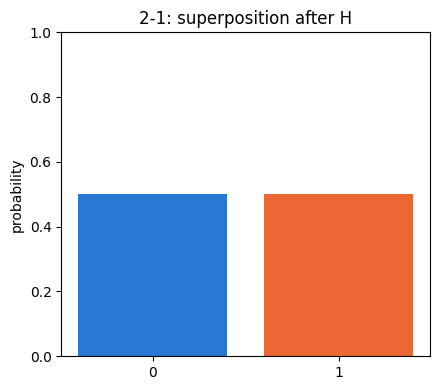

In [2]:

import pennylane as qml
from pennylane import numpy as np
import numpy as std_np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

SEED = 1234
dev = qml.device("default.qubit", wires=1, seed=SEED)  # 큐빗 1개 = 입자 1개


# %%
# ===========================================================
#  2-1: 중첩 (superposition) — H 게이트
# ===========================================================
print("=" * 60)
print("lab2-1: 중첩 — 두 슬릿을 동시에 통과")
print("=" * 60)


@qml.qnode(dev)
def superposition_probs():
    qml.Hadamard(0)                 # |0> -> (|0>+|1>)/sqrt(2)
    return qml.probs(wires=0)


probs = superposition_probs()
print(f"\nH|0> 상태의 측정 확률:  P(0)={float(probs[0]):.3f},  P(1)={float(probs[1]):.3f}")
print("=> 아직 어느 쪽도 아닌 '중첩' 상태. 확률은 정확히 50:50.")

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.bar(["0", "1"], [float(probs[0]), float(probs[1])],
       color=["#2a78d6", "#eb6834"])
ax.set_ylim(0, 1)
ax.set_ylabel("probability")
ax.set_title("2-1: superposition after H")
plt.tight_layout()
plt.show()



In [4]:

# %%
# ===========================================================
#  2-2: 단일 샷 = 측정 (measurement)
# ===========================================================
print("\n" + "=" * 60)
print("lab2-2: 단일 샷 — 광자 하나가 스크린 한 점에 찍힌다")
print("=" * 60)


@qml.qnode(dev)
def superposition_sample():
    qml.Hadamard(0)
    return qml.sample()             # 한 번 측정한 결과 (0 또는 1)


# shots=1 을 여러 번 반복: 매번 무작위로 0 또는 1
single_shots = [int(std_np.ravel(qml.set_shots(superposition_sample, shots=1)())[0])
                for _ in range(20)]
print("\n단일 샷 20회:", single_shots)
print("=> 중첩 상태를 '측정'하면 그때그때 0 또는 1로 무작위 붕괴한다.")
print("   다음에 무엇이 나올지는 예측할 수 없다 (측정의 본질).")




lab2-2: 단일 샷 — 광자 하나가 스크린 한 점에 찍힌다

단일 샷 20회: [0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0]
=> 중첩 상태를 '측정'하면 그때그때 0 또는 1로 무작위 붕괴한다.
   다음에 무엇이 나올지는 예측할 수 없다 (측정의 본질).



lab2-3: 샷을 쌓으면 통계가 드러난다

4000 샷:  0 -> 1968회,  1 -> 2032회  (약 50:50)
=> 개별 측정은 무작위지만, 많이 쌓으면 확률(50:50)이 드러난다.
   하지만 H만으로는 밋밋한 50:50 — 아직 '무늬'가 없다.


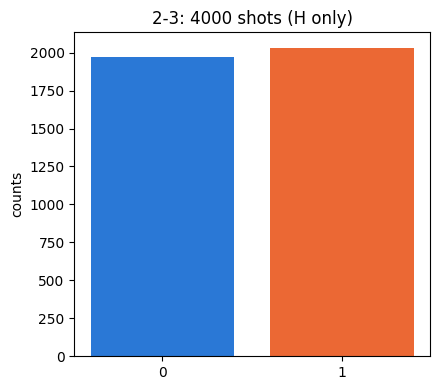

In [5]:

# %%
# ===========================================================
#  2-3: 샷 통계 (shot statistics)
# ===========================================================
print("\n" + "=" * 60)
print("lab2-3: 샷을 쌓으면 통계가 드러난다")
print("=" * 60)


@qml.qnode(dev)
def superposition_counts():
    qml.Hadamard(0)
    return qml.counts()


counts = qml.set_shots(superposition_counts, shots=4000)()
n0 = int(counts.get("0", 0))
n1 = int(counts.get("1", 0))
print(f"\n4000 샷:  0 -> {n0}회,  1 -> {n1}회  (약 50:50)")
print("=> 개별 측정은 무작위지만, 많이 쌓으면 확률(50:50)이 드러난다.")
print("   하지만 H만으로는 밋밋한 50:50 — 아직 '무늬'가 없다.")

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.bar(["0", "1"], [n0, n1], color=["#2a78d6", "#eb6834"])
ax.set_ylabel("counts")
ax.set_title("2-3: 4000 shots (H only)")
plt.tight_layout()
plt.show()




lab2-4: 위상을 넣으면 간섭 무늬가 나타난다

phi=0    -> P(0)=1.00  (보강간섭: 항상 0)
phi=pi   -> P(0)=0.00  (상쇄간섭: 항상 1)
=> 중간엔 50:50 중첩인데도, 위상에 따라 결과가 결정적으로 갈린다 = 파동성.


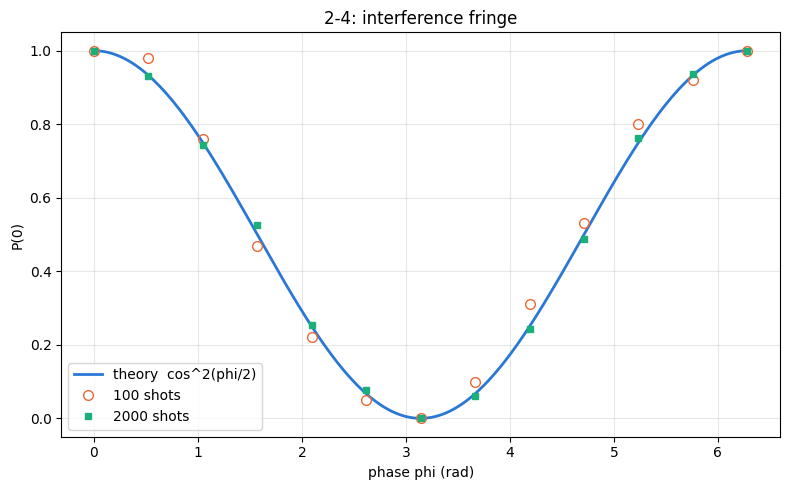

In [6]:

# %%
# ===========================================================
#  2-4: 간섭 (interference) — H - P(phi) - H
# ===========================================================
print("\n" + "=" * 60)
print("lab2-4: 위상을 넣으면 간섭 무늬가 나타난다")
print("=" * 60)


@qml.qnode(dev)
def mz_probs(phi):
    qml.Hadamard(0)          # 슬릿 통과 (중첩)
    qml.PhaseShift(phi, 0)   # 두 경로의 길이차 (위상)
    qml.Hadamard(0)          # 스크린에서 재결합 (간섭)
    return qml.probs(wires=0)


@qml.qnode(dev)
def mz_counts(phi):
    qml.Hadamard(0)
    qml.PhaseShift(phi, 0)
    qml.Hadamard(0)
    return qml.counts()


def p0_shots(phi, shots):
    c = qml.set_shots(mz_counts, shots=shots)(phi)
    return c.get("0", 0) / shots


# 위상 phi 를 0 ~ 2pi 로 훑기
phis = std_np.linspace(0, 2 * np.pi, 200)
p0_theory = [float(mz_probs(p)[0]) for p in phis]         # = cos^2(phi/2)

phis_s = std_np.linspace(0, 2 * np.pi, 13)
p0_100 = [p0_shots(p, 100) for p in phis_s]
p0_2000 = [p0_shots(p, 2000) for p in phis_s]

print(f"\nphi=0    -> P(0)={float(mz_probs(0.0)[0]):.2f}  (보강간섭: 항상 0)")
print(f"phi=pi   -> P(0)={float(mz_probs(np.pi)[0]):.2f}  (상쇄간섭: 항상 1)")
print("=> 중간엔 50:50 중첩인데도, 위상에 따라 결과가 결정적으로 갈린다 = 파동성.")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(phis, p0_theory, "-", color="#2a78d6", lw=2, label="theory  cos^2(phi/2)")
ax.plot(phis_s, p0_100, "o", color="#eb6834", mfc="none", ms=7, label="100 shots")
ax.plot(phis_s, p0_2000, "s", color="#1baf7a", ms=5, label="2000 shots")
ax.set_xlabel("phase phi (rad)")
ax.set_ylabel("P(0)")
ax.set_title("2-4: interference fringe")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



lab2-5: '어느 슬릿?'을 측정하면 무늬가 사라진다

which-path 측정 후 P(0): [np.float64(0.51), np.float64(0.52), np.float64(0.5), np.float64(0.5), np.float64(0.5), np.float64(0.5), np.float64(0.47)] ...
=> 경로를 '알면' 파동성이 죽어 무늬가 평평한 50:50 이 된다 (상보성).


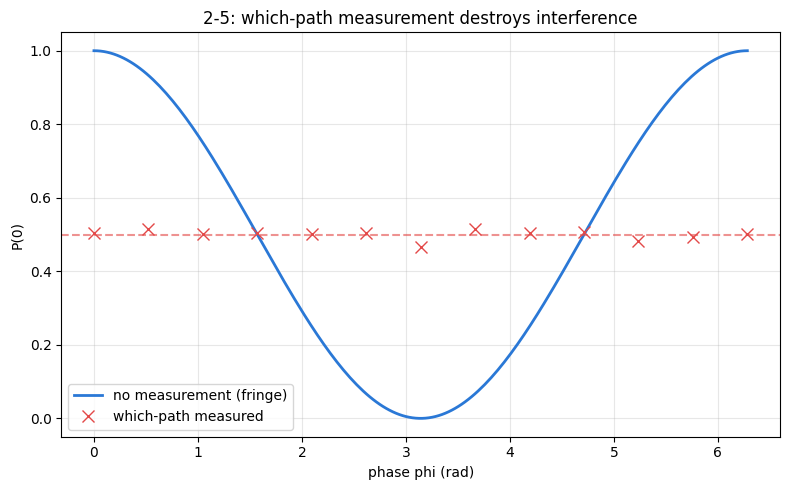

In [7]:


# %%
# ===========================================================
#  2-5: (심화) 측정이 간섭을 없앤다 — 상보성
# ===========================================================
print("\n" + "=" * 60)
print("lab2-5: '어느 슬릿?'을 측정하면 무늬가 사라진다")
print("=" * 60)


@qml.qnode(dev)
def whichpath_counts(phi):
    qml.Hadamard(0)          # 슬릿 통과 (중첩)
    qml.measure(0)           # <-- 어느 슬릿인지 '측정' -> 경로 정보 획득, 붕괴
    qml.PhaseShift(phi, 0)
    qml.Hadamard(0)
    return qml.counts()


def p0_whichpath(phi, shots=2000):
    c = qml.set_shots(whichpath_counts, shots=shots)(phi)
    return c.get("0", 0) / shots


p0_wp = [p0_whichpath(p) for p in phis_s]

print("\nwhich-path 측정 후 P(0):",
      [round(v, 2) for v in p0_wp[:7]], "...")
print("=> 경로를 '알면' 파동성이 죽어 무늬가 평평한 50:50 이 된다 (상보성).")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(phis, p0_theory, "-", color="#2a78d6", lw=2, label="no measurement (fringe)")
ax.plot(phis_s, p0_wp, "x", color="#e34948", ms=8, label="which-path measured")
ax.axhline(0.5, color="#e34948", ls="--", alpha=0.6)
ax.set_xlabel("phase phi (rad)")
ax.set_ylabel("P(0)")
ax.set_title("2-5: which-path measurement destroys interference")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [9]:

# %%
# ===========================================================
#  2-6: phi 슬라이더 — 무늬가 실시간으로 움직인다
# ===========================================================
# Colab/Jupyter 에서 아래 셀을 실행하면 슬라이더가 나타난다.
# phi 를 드래그하면 (좌) 측정 확률 막대와 (우) 무늬 위의 점이 함께 움직인다.
from ipywidgets import interact, FloatSlider


def show_phi(phi):
    p0 = float(mz_probs(phi)[0])
    p1 = 1.0 - p0
    fig, (a, b) = plt.subplots(1, 2, figsize=(11, 4))

    # (좌) 현재 phi 에서의 측정 확률
    a.bar(["0", "1"], [p0, p1], color=["#2a78d6", "#eb6834"])
    a.set_ylim(0, 1)
    a.set_ylabel("probability")
    a.set_title(f"measurement outcome  (phi={phi:.2f})")

    # (우) 간섭 무늬 위에 현재 위치 표시
    b.plot(phis, p0_theory, "-", color="#2a78d6", lw=2)
    b.plot([phi], [p0], "o", color="#eb6834", ms=12)
    b.set_xlabel("phase phi (rad)")
    b.set_ylabel("P(0)")
    b.set_ylim(-0.05, 1.05)
    b.set_title("interference fringe")
    b.grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()


interact(show_phi,
         phi=FloatSlider(min=0.0, max=2 * np.pi, step=0.05, value=np.pi / 3,
                         description="phi"))

interactive(children=(FloatSlider(value=1.0471975511965976, description='phi', max=6.283185307179586, step=0.0…

<function __main__.show_phi(phi)>